# ZQE with Gaussian MAP Encoder — Generic h(Y)

Implements the **ZQE estimator** for a Poisson GLLVM where the sufficient
statistic `h(Y)` is selectable independently for:

- **Encoder**: closed-form Gaussian MAP  
  `z_hat(y) = (W^T W + λI)^{-1} W^T (h_enc(y) - b)`
- **Decoder**: ZQE cross-term  
  `ℒ = E[h_dec(y)·η(ẑ(y))] − E_θ[h_dec(y_sim)·η(ẑ(y_sim))]`

Decoder parameters `(W, b)` are optimised with **SGD**.

> Same algorithm as `simulation_sparse/exp_A_sparse_loadings.ipynb` but with
> h(Y) fully configurable for both encoder and decoder.

## 1. Imports and Configuration

In [1]:
%load_ext autoreload
%autoreload 2

import os, random, copy, math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.optim.swa_utils import AveragedModel
from scipy.spatial import procrustes as scipy_procrustes

from gllvm.simulations import make_sparse, simulate

# ── reproducibility ───────────────────────────────────────────────────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

# ── experiment config ─────────────────────────────────────────────────────────
NL   = 10       # total latent dimensions (all active, dense W — no mask)
NR   = 5000     # number of responses
NS   = 100     # number of observations
WZS  = 1.5     # loading scale

# optimiser config
EPOCHS     = 2000
LR_INIT    = 1.0
FLAT_FRAC  = 0.2
RM_ALPHA   = 0.5
RM_A       = 2.0
BATCH_SIZE = NS
N_MC       = 4
EMA_DECAY  = 0.95
EMA_START  = 20
RIDGE      = 1.0

print(f"device={device}  NL={NL}  NR={NR}  NS={NS}  (dense W, no mask)")


device=cuda  NL=10  NR=5000  NS=100  (dense W, no mask)


## 2. Data Generation

In [2]:
torch.manual_seed(SEED)

# Dense GLLVM: all NL latents active, no responses_per_latent mask
g0 = make_sparse(
    n_latent=NL,
    poisson=NR,
    active_latent=NL,   # all dims active
    wz_scale=WZS,
    # responses_per_latent=None (default) → dense W, no structural zeros
).to(device)

y_all, z_all = simulate(g0, n_samples=NS, device=device)

print(f"y shape: {y_all.shape}   mean count: {y_all.float().mean():.2f}   "
      f"sparsity: {(y_all == 0).float().mean():.2%}")
print(f"W_true: {g0.wz.shape}  ||W||_F = {g0.wz.norm():.3f}")
print(f"W nnz per column: {[(g0.wz[:,q]!=0).sum().item() for q in range(NL)]}")


y shape: torch.Size([100, 5000])   mean count: 890.09   sparsity: 45.57%
W_true: torch.Size([5000, 10])  ||W||_F = 336.918
W nnz per column: [5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]


## 3. h(Y) Transformation Registry

Each transform can be selected independently for encoder and decoder.
All functions accept a float tensor and return a float tensor of the same shape.

In [3]:
H_REGISTRY = {
    # canonical Poisson sufficient statistic
    "identity": lambda y: y.float(),

    # variance-stabilising / numerically stable transforms
    "log1p":    lambda y: torch.log1p(y.float()),
    "sqrt":     lambda y: torch.sqrt(y.float().clamp_min(0.0)),
    "anscombe": lambda y: 2.0 * torch.sqrt(y.float().clamp_min(0.0) + 3.0 / 8.0),

    # combinations (equal-weight averages)
    "log1p+sqrt":     lambda y: (torch.log1p(y.float()) + torch.sqrt(y.float().clamp_min(0.0))) / 2.0,
    "log1p+anscombe": lambda y: (torch.log1p(y.float()) +
                                 2.0 * torch.sqrt(y.float().clamp_min(0.0) + 3.0 / 8.0)) / 2.0,
}


def get_h(name: str):
    """Return the h function by name, with a clear error if unknown."""
    if name not in H_REGISTRY:
        raise ValueError(f"Unknown h: {name!r}. Choose from {list(H_REGISTRY)}")
    return H_REGISTRY[name]


# quick sanity check
_y_test = torch.tensor([0.0, 1.0, 4.0, 9.0])
print("h(Y) values on [0, 1, 4, 9]:")
for name, fn in H_REGISTRY.items():
    print(f"  {name:<20}: {fn(_y_test).numpy().round(3).tolist()}")


h(Y) values on [0, 1, 4, 9]:
  identity            : [0.0, 1.0, 4.0, 9.0]
  log1p               : [0.0, 0.6930000185966492, 1.6089999675750732, 2.302999973297119]
  sqrt                : [0.0, 1.0, 2.0, 3.0]
  anscombe            : [1.225000023841858, 2.3450000286102295, 4.183000087738037, 6.124000072479248]
  log1p+sqrt          : [0.0, 0.847000002861023, 1.8049999475479126, 2.6510000228881836]
  log1p+anscombe      : [0.6119999885559082, 1.5190000534057617, 2.8959999084472656, 4.2129998207092285]


## 4. Gaussian MAP Encoder

Closed-form solution assuming `h_enc(y) | z ~ N(Wz + b, σ²I)` with prior `z ~ N(0, I)`:

$$\hat{z}(y;\, W,b) = (W^\top W + \lambda I_Q)^{-1}\, W^\top\,\bigl(h_\text{enc}(y) - b\bigr)$$

where `λ = σ²` (ridge = 1 by default, matching the N(0,I) prior).
No learnable parameters. Recomputes the Cholesky every call so it tracks W as it evolves.

In [4]:
class GaussianMAPEncoder(nn.Module):
    """
    Parameter-free Gaussian MAP encoder with selectable h_enc.

    Assumes proxy model:
        h_enc(y) | z  ~  N(W z + b,  ridge * I_P)
        z             ~  N(0, I_Q)

    Closed-form MAP:
        z_hat(y) = (W^T W + ridge * I_Q)^{-1} W^T (h_enc(y) - b)

    Parameters
    ----------
    gllvm   : GLLVM module (provides .wz [P, Q] and .bias [P])
    h_enc   : str or callable — transformation applied to y before solving
    ridge   : float — σ² / prior precision ratio (default 1.0)
    """

    def __init__(self, gllvm, h_enc="log1p", ridge: float = 1.0):
        super().__init__()
        self.gllvm = gllvm
        self.h_fn  = get_h(h_enc) if isinstance(h_enc, str) else h_enc
        self.ridge = ridge

    def forward(self, y: torch.Tensor) -> torch.Tensor:
        """
        y : [N, P]  — raw counts
        returns z_hat : [N, Q]
        """
        W = self.gllvm.wz           # [P, Q]
        b = (self.gllvm.bias
             if self.gllvm.bias is not None
             else torch.zeros(W.shape[0], device=W.device, dtype=W.dtype))

        hy = self.h_fn(y)           # [N, P]  — transformed
        rhs = (hy - b) @ W          # [N, Q]  = (h(y) - b)^T W

        A = self.ridge * torch.eye(W.shape[1], device=W.device, dtype=W.dtype) + W.T @ W  # [Q, Q]
        z_hat = torch.linalg.solve(A, rhs.T).T   # [N, Q]
        return z_hat

    def sample(self, y):
        """Drop-in for Encoder.sample() protocol."""
        z = self.forward(y)
        return z, z, torch.full_like(z, float("-inf"))

    def loss(self, y, gllvm=None, **kwargs):
        dummy = next(self.gllvm.parameters())
        return torch.zeros(1, device=dummy.device, requires_grad=True), 0.0


# ── quick shape check ─────────────────────────────────────────────────────────
with torch.no_grad():
    _enc_test = GaussianMAPEncoder(g0, h_enc="log1p", ridge=RIDGE)
    _z_test   = _enc_test.forward(y_all[:5])
    print(f"Encoder output shape: {_z_test.shape}  (expected [5, {NL}])")
    print(f"  z_hat[0] = {_z_test[0].cpu().numpy().round(4)}")


Encoder output shape: torch.Size([5, 10])  (expected [5, 10])
  z_hat[0] = [ 0.0681  1.027  -0.1215  0.3966 -0.8748  0.3228 -0.2982 -0.3762  0.2586
 -0.5599]


## 5. ZQE Loss

The ZQE cross-term objective with generic `h_dec`:

$$\mathcal{L}(W, b) =
  \underbrace{\frac{1}{N}\sum_{i=1}^N h_\text{dec}(y_i)^\top \eta(\hat{z}(y_i))}_{\text{real term}}
  -
  \underbrace{\frac{1}{M}\sum_{m=1}^M h_\text{dec}(y_m^\text{sim})^\top \eta(\hat{z}(y_m^\text{sim}))}_{\text{centering term}}$$

where `η(z) = Wz + b` is the linear predictor and `ẑ(y)` is the Gaussian MAP encoder.
Both `h_enc` (inside the encoder) and `h_dec` (in the cross-term) are configurable independently.

In [5]:
def zqe_loss(gllvm, encoder, h_dec_fn, y_real: torch.Tensor,
             y_sim: torch.Tensor) -> torch.Tensor:
    """
    ZQE cross-term loss (to minimise the negative).

    z is treated as a *fixed imputation* (no gradient through the encoder).
    Gradient flows only through W and b inside η(z) = Wz + b, exactly as in
    exp_A_sparse_loadings where enc.sample() is called inside no_grad().

    Parameters
    ----------
    gllvm    : GLLVM module with .wz [P, Q] and .bias [P]
    encoder  : GaussianMAPEncoder (or any encoder with .forward(y) -> [N, Q])
    h_dec_fn : callable — h applied to y in the cross-term (decoder statistic)
    y_real   : [N, P] — observed counts
    y_sim    : [M, P] — simulated counts from current model

    Returns
    -------
    loss : scalar tensor (negative of ZQE objective — minimise this)
    """
    # ── encode with no grad — z is a fixed imputation ─────────────────────────
    with torch.no_grad():
        z_real = encoder.forward(y_real)    # [N, Q]  detached
        z_sim  = encoder.forward(y_sim)     # [M, Q]  detached

    # ── linear predictor η(z) = Wz + b  (gradient flows here) ────────────────
    eta_real = gllvm.forward(z_real)    # [N, P]
    eta_sim  = gllvm.forward(z_sim)     # [M, P]

    # ── cross-term with h_dec ─────────────────────────────────────────────────
    hy_real = h_dec_fn(y_real)          # [N, P]
    hy_sim  = h_dec_fn(y_sim)           # [M, P]

    real_term = (hy_real * eta_real).sum(dim=-1).mean()
    cent_term = (hy_sim  * eta_sim ).sum(dim=-1).mean()

    return -(real_term - cent_term)     # minimise → maximise ZQE objective


print("zqe_loss defined ✓  (encoder runs under no_grad — z is a fixed imputation)")


zqe_loss defined ✓  (encoder runs under no_grad — z is a fixed imputation)


## 6. Training Utilities

Procrustes error, LR schedule, EMA, and the main `run_zqe` loop —
mirrors `exp_A_sparse_loadings` but with `h_enc` / `h_dec` as explicit arguments.

In [6]:
# ── Procrustes error ──────────────────────────────────────────────────────────

def _best_rotation(A, B):
    U, _, Vt = np.linalg.svd(A.T @ B)
    R1 = (U @ Vt).T
    D = np.eye(U.shape[0]); D[-1, -1] = -1.0
    R2 = (U @ D @ Vt).T
    return R1 if np.linalg.norm(A - B @ R1) <= np.linalg.norm(A - B @ R2) else R2


def procr(g_true, g_est):
    a = g_true.wz.detach().cpu().numpy()
    b = g_est.wz.detach().cpu().numpy()
    R = _best_rotation(a, b)
    return float(np.linalg.norm(a - b @ R) / np.linalg.norm(a))


# ── Robbins–Monro LR schedule ─────────────────────────────────────────────────

def _flat_rm_scheduler(opt, epochs, flat_frac=0.1, rm_alpha=0.6, rm_a=1.0):
    flat_ep = int(flat_frac * epochs)
    def lr_lambda(ep):
        if ep < flat_ep:
            return 1.0
        t = ep - flat_ep + 1
        return (rm_a / (rm_a + t)) ** rm_alpha
    return torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)


# ── Main training loop ────────────────────────────────────────────────────────

def run_zqe(g0_ref, h_enc: str, h_dec: str,
            label: str, colour: str,
            lr_init: float = LR_INIT,
            flat_frac: float = FLAT_FRAC,
            rm_alpha: float = RM_ALPHA,
            rm_a: float = RM_A,
            epochs: int = EPOCHS,
            n_mc: int = N_MC,
            ridge: float = RIDGE,
            batch_size: int = BATCH_SIZE,
            ema_decay: float = EMA_DECAY,
            ema_start: int = EMA_START):

    g = copy.deepcopy(g0_ref)
    with torch.no_grad():
        nn.init.normal_(g.wz, std=WZS)
        nn.init.zeros_(g.bias)

    h_enc_fn = get_h(h_enc)
    h_dec_fn = get_h(h_dec)
    encoder  = GaussianMAPEncoder(g, h_enc=h_enc_fn, ridge=ridge)

    opt       = torch.optim.SGD(list(g.parameters()), lr=lr_init)
    scheduler = _flat_rm_scheduler(opt, epochs, flat_frac=flat_frac,
                                   rm_alpha=rm_alpha, rm_a=rm_a)

    ema_fn    = lambda avg, cur, n: ema_decay * avg + (1 - ema_decay) * cur
    ema_model = AveragedModel(g, avg_fn=ema_fn)
    ema_active = False

    h_err, h_err_ema, h_loss = [], [], []

    print(f"\n[{label}]  h_enc={h_enc}  h_dec={h_dec}  "
          f"lr={lr_init:.1e}  start Proc={procr(g0_ref, g):.4f}")

    for ep in range(epochs):
        ep_loss, n_batches = 0.0, 0
        perm = torch.randperm(len(y_all), device=device)

        for i in range(0, len(y_all), batch_size):
            batch = y_all[perm[i: i + batch_size]]

            loss_acc = torch.zeros(1, device=device)
            for _ in range(n_mc):
                with torch.no_grad():
                    z_q   = g.sample_z(len(batch))
                    y_sim = g.sample(z=z_q)
                loss_acc = loss_acc + zqe_loss(g, encoder, h_dec_fn, batch, y_sim)
            loss = loss_acc / n_mc

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(list(g.parameters()), 5.0)
            if not torch.isnan(loss):
                opt.step()

            ep_loss   += loss.item()
            n_batches += 1

        scheduler.step()

        if ep >= ema_start:
            ema_model.update_parameters(g)
            ema_active = True

        h_err.append(procr(g0_ref, g))
        h_err_ema.append(procr(g0_ref, ema_model.module) if ema_active else h_err[-1])
        h_loss.append(ep_loss / n_batches)

        if (ep + 1) % max(1, epochs // 5) == 0:
            print(f"  ep {ep+1:4d}/{epochs}  loss={h_loss[-1]:+.4f}"
                  f"  Proc={h_err[-1]:.4f}  EMA={h_err_ema[-1]:.4f}"
                  f"  lr={opt.param_groups[0]['lr']:.2e}")

    print(f"[{label}]  FINAL  raw={h_err[-1]:.4f}  EMA={h_err_ema[-1]:.4f}")
    return {"err": h_err, "err_ema": h_err_ema, "loss": h_loss,
            "colour": colour, "label": label,
            "h_enc": h_enc, "h_dec": h_dec, "g": g}


print("run_zqe defined ✓")


run_zqe defined ✓


## 7. Run Experiments

Compare different choices of `(h_enc, h_dec)`.  
The first arm (`log1p / log1p`) reproduces the best arm from `simulation_sparse`.

In [7]:
# ── Experiment arms: (h_enc, h_dec, label, colour) ───────────────────────────
ARMS = [
    ("log1p",         "log1p",         "enc=log1p  / dec=log1p",         "tab:blue"),
    # ("sqrt",          "sqrt",          "enc=sqrt   / dec=sqrt",           "tab:orange"),
    # ("log1p+sqrt",    "log1p+sqrt",    "enc=mix    / dec=mix",            "tab:green"),
    # ("log1p",         "sqrt",          "enc=log1p  / dec=sqrt",           "tab:red"),
    # ("sqrt",          "log1p",         "enc=sqrt   / dec=log1p",          "tab:purple"),
    # ("anscombe",      "anscombe",      "enc=ansc   / dec=ansc",           "tab:brown"),
]

results = {}
torch.manual_seed(SEED)

for h_enc, h_dec, label, colour in ARMS:
    res = run_zqe(g0, h_enc=h_enc, h_dec=h_dec, label=label, colour=colour)
    results[label] = res



[enc=log1p  / dec=log1p]  h_enc=log1p  h_dec=log1p  lr=1.0e+00  start Proc=1.3840
  ep  400/2000  loss=+110.3730  Proc=0.3266  EMA=0.3230  lr=8.16e-01
  ep  800/2000  loss=-42.4756  Proc=0.3333  EMA=0.3330  lr=7.04e-02
  ep 1200/2000  loss=+719.2524  Proc=0.3360  EMA=0.3358  lr=4.99e-02
  ep 1600/2000  loss=-650.0566  Proc=0.3391  EMA=0.3389  lr=4.08e-02
  ep 2000/2000  loss=-135.2935  Proc=0.3401  EMA=0.3401  lr=3.53e-02
[enc=log1p  / dec=log1p]  FINAL  raw=0.3401  EMA=0.3401


## 8. Results and Diagnostics

NameError: name 'ACT' is not defined

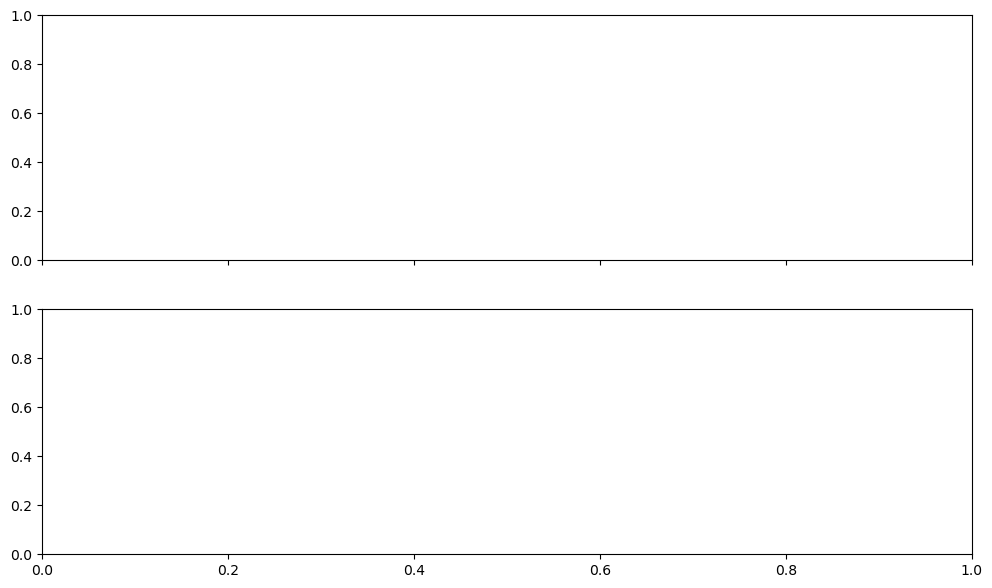

In [8]:
def smooth(x, w=10):
    if w <= 1:
        return np.array(x)
    return np.convolve(x, np.ones(w) / w, mode="valid")


SMOOTH = 10
xs = np.arange(SMOOTH - 1, EPOCHS)

fig, (ax_loss, ax_proc) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle(f"ZQE Gaussian MAP — NL={NL} ACT={ACT} NR={NR} NS={NS}")

for label, res in results.items():
    col = res["colour"]
    ax_loss.plot(xs, smooth(res["loss"], SMOOTH),   color=col, lw=1.5, label=label)
    ax_proc.plot(xs, smooth(res["err"],  SMOOTH),   color=col, lw=1.0, alpha=0.4)
    ax_proc.plot(xs, smooth(res["err_ema"], SMOOTH), color=col, lw=2.0,
                 label=f"{label}  EMA={res['err_ema'][-1]:.3f}")

ax_loss.axhline(0, color="gray", ls=":", lw=0.8)
ax_loss.set_ylabel("ZQE loss  (↓ better)"); ax_loss.legend(fontsize=7)
ax_proc.set_ylabel("Procrustes error  (↓ better)"); ax_proc.legend(fontsize=7)
ax_proc.set_xlabel("Epoch")
plt.tight_layout(); plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Arm':<42}  {'h_enc':<14}  {'h_dec':<14}  {'raw':>7}  {'EMA':>7}")
print("─" * 90)
for label, res in sorted(results.items(), key=lambda kv: kv[1]["err_ema"][-1]):
    print(f"{label:<42}  {res['h_enc']:<14}  {res['h_dec']:<14}"
          f"  {res['err'][-1]:>7.4f}  {res['err_ema'][-1]:>7.4f}")


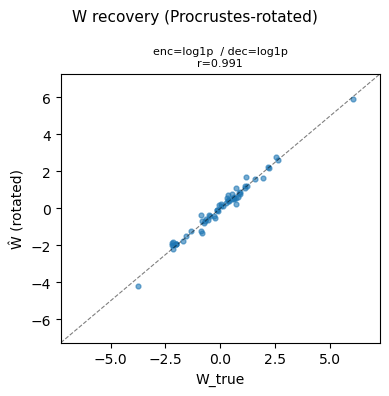

In [ ]:
# ── W recovery scatter for each arm ──────────────────────────────────────────
n_arms = len(results)
fig2, axes = plt.subplots(1, n_arms, figsize=(4 * n_arms, 4))
if n_arms == 1:
    axes = [axes]

w_true = g0.wz.detach().cpu().numpy().ravel()

for ax, (label, res) in zip(axes, results.items()):
    w_est = res["g"].wz.detach().cpu().numpy()
    R = _best_rotation(g0.wz.detach().cpu().numpy(), w_est)
    w_rot = (w_est @ R).ravel()
    r = float(np.corrcoef(w_true, w_rot)[0, 1])
    ax.scatter(w_true, w_rot, s=12, alpha=0.6, color=res["colour"])
    lim = max(np.abs(w_true).max(), np.abs(w_rot).max()) * 1.2
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8, alpha=0.5)
    ax.set_title(f"{label}\nr={r:.3f}", fontsize=8)
    ax.set_xlabel("W_true"); ax.set_ylabel("Ŵ (rotated)")
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

fig2.suptitle("W recovery (Procrustes-rotated)", fontsize=11)
plt.tight_layout(); plt.show()
